**PRE-PROCESSING**

***I. Introduction***

The purpose of Pre-Processing is to prepare customer-level featuers for regression modeling.  I will apply EDA-justified transformations, ensure comparable feature scales, and prevent data leakage.  Also I will ensure reproducibility.

In [28]:
#Imports

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

***II. Confirm Final Feature Set***

In [29]:
# Load Data

df = pd.read_csv('../data/processed/capstone3_customer_modeling_table_For_EDA.csv')
df.head()

,CustomerID,recency,frequency,monetary,avg_order_value,target_60day_revenue
0,12346,265,1,77183.60,77183.600000,0.00
1,12347,69,5,2790.86,558.172000,1519.14
2,12348,14,4,1797.24,449.310000,0.00
3,12350,249,1,334.40,334.400000,0.00
4,12352,11,7,2194.31,313.472857,311.73


From my EDA, I've retained my target "target_60day_revenue", as well as my features: "recency", "frequency", "monetary", "avg_order_value". EDA confirmed these are all strong drivers of near-term revenue.  I will exclude CustomerID from my modeling.

From my EDA, one can see heavy right skew in "monetary", "frequency", "avg_ord_value", and "target_60day_revenue."  When I applied log transformations, the respective distributions of the variables became more symmetric.  Relationships between several bivariate plots were  clarified and generally all plots had better interpretability.  The visual and statistical evidence supports log-transformed features for modeling, as well as log-transforming the target for regression stability.

"Recency" will not be log-transformed as it was already well-behaved, and its interpretationi n days is meaningful for business use.

***III. Apply Log-Transformations***

The goal with log-transformations is to reduce skew, stabilize variance and reduce regression performance.  I will log transform "monetary","frequency", "avg_ord_value", as well as, my target variable "target_60day_revenue."  From the EDA, one could see that "monetary" and "aov" were heavily skewed.  After log-scaling, they became relatively normal.  Frequency also benefited from scale compression.  Target was also extremely skewed.

In [30]:
### Log-Transformations of features and targets

df['log_monetary'] = np.log1p(df['monetary'])
df['log_frequency'] = np.log1p(df['frequency'])
df['log_aov'] = np.log1p(df['avg_order_value'])
df['log_target'] = np.log1p(df['target_60day_revenue'])

In [31]:
### Confirm log-transformed features in the DataFrame
df.head()

,CustomerID,recency,frequency,monetary,avg_order_value,target_60day_revenue,log_monetary,log_frequency,log_aov,log_target
0,12346,265,1,77183.60,77183.600000,0.00,11.253955,0.693147,11.253955,0.000000
1,12347,69,5,2790.86,558.172000,1519.14,7.934463,1.791759,6.326457,7.326558
2,12348,14,4,1797.24,449.310000,0.00,7.494564,1.609438,6.109936,0.000000
3,12350,249,1,334.40,334.400000,0.00,5.815324,0.693147,5.815324,0.000000
4,12352,11,7,2194.31,313.472857,311.73,7.694079,2.079442,5.750898,5.745340


***IV. Define Feature Matrix (X) and Target (y)***

The goal for this step is to separate predictors from the target variable. I will exclude 'CustomerID', the "raw" 'monetary' ,'frequency', and 'aov' variables, as well as the "raw" target.  This will avoid leakage and duplication of features.  Ultimately, it will keep my model clean and interpretable.

In [32]:
### Defining Features
X = df[['log_monetary', 'log_frequency', 'log_aov', 'recency']]
y = df['log_target']

In [33]:
### Sanity Checks

X.isnull().sum()

log_monetary     0
log_frequency    0
log_aov          0
recency          0
dtype: int64

In [34]:
y.isnull().sum()

np.int64(0)

All zeroes.  Just what we wanted.

In [35]:
X.shape

(3731, 4)

In [36]:
y.shape

(3731,)

Same number of rows.

***V. Train/Test Split***

Want to make sure the train/test split is random and split 70/30.

In [37]:
### Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

***VI. Standardize Features***

I wish to ensure comparable magnitudes across predictors.  Even after log-transform, one can see 'receny' may range from 0-265, while logged variables range from 0-10.  Standard scaling ensures that linear regression coefficients are comparible.

In [38]:
### Standard Scaler - fitting and transforming traning data.  ONLY transforming testing data.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
### Sanity Checks

X_train_scaled.shape

(2611, 4)

In [40]:
X_test_scaled.shape

(1120, 4)

In [41]:
X_train_scaled.mean()

np.float64(5.646787348533926e-17)

In [42]:
X_train_scaled.std()

np.float64(1.0)

In [43]:
y_train.shape

(2611,)

In [44]:
y_test.shape

(1120,)

Test sets and train sets have, respectively, the same amount of rows.

In [45]:
np.isnan(X_train_scaled).sum()

np.int64(0)

No zero values.  Everything is clean.  On to Modeling.

***VII.Conclusion***

Through the pre-processing step, I implemented EDA decisions and created clean modeling inputs.  I have a clean feature matrix (X), log-stabilized predictors, a log-stabilized target(y), scaled training/testing data, and a fully modeling-ready data set.

One thing to keep in mind: Because I log-transformed the target, my model will ultimately predict *log(Revenue + 1)*.  I must remember to convert the predictions back to sterling, as this will be important for business interpretation.

In [46]:
### Saving pre-processed DataFrame
filename = 'preprocessed_RFM_data.csv'
df.to_csv(filename, index=False) 

**MODELING**

***I. Training the Baseline Models***

I will use my data to train the following models:  Ridge Regression, Random Forest, and Gradient Boosting.  All parameters will be default.  This will give hte baseline RSME before hyperparameter tuning.

In [47]:
### Loading the libraries (Random Forest Already uploaded)

### - Ridge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

### - Gradient Booster
from sklearn.ensemble import GradientBoostingRegressor


In [48]:
### - Ridge Regressor Baseline

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge baseline RMSE:", ridge_rmse)

Ridge baseline RMSE: 2.76213305346127


In [49]:
### - Random Forest Baseline

rf = RandomForestRegressor(random_state=21)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest baseline RMSE:", rf_rmse)

Random Forest baseline RMSE: 2.9936558076581856


In [50]:
### - Gradient Boosting Baseline

gb = GradientBoostingRegressor(random_state = 21)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting baseline RMSE:", gb_rmse)

Gradient Boosting baseline RMSE: 2.75841468472497


From the results one can see that Gradient Boosting is currently the best baseline model, since it has the smallest RMSE.  Ridge is a very close second.  Random Forest is the worst right now.  It will likely get much better after hyperparameter tuning.

***II. Hyperparameter Tuning***

I will now tune each model for optimal hyperparameters using GridSearchCV.

In [51]:
###  - GridSearchCV with Ridge

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv = 5, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train)

print("Best alpha:", ridge_cv.best_params_)

Best alpha: {'alpha': 1}


In [52]:
### - Get the best model and evaluate on the test set

best_ridge = ridge_cv.best_estimator_

y_pred = best_ridge.predict(X_test_scaled)

ridge_cv_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Tuned Ridge RMSE:", ridge_cv_rmse)

Tuned Ridge RMSE: 2.76213305346127


My tuned Ridge RMSE is identical to my baseline Ridge RMSE.  We see this because GridSearchCV found that the default Ridge parameter was already optimal (alpha = 1.0). Thus regularization strength does not significantly impact performance.  Overfitting is likely minimal with current feature set.

In [53]:
### - GridSearch CV with Random Forest. Note: Random Forest does not require scaled data, so X_train, will be used instead of X_train_scaled


param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor()                 
grid_rf = GridSearchCV(rf, param_grid_rf, cv = 5, scoring='neg_root_mean_squared_error', n_jobs=-1)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [54]:
### - Get the best model and evaluate on the test set

best_rf = grid_rf.best_estimator_
print("Best parameters:", grid_rf.best_params_)

y_pred = best_rf.predict(X_test)

rf_cv_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Tuned Random Forest RMSE:", rf_cv_rmse)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest RMSE: 2.7585562015153537


From these results, one can see that Random Forest improved slightly from the baseline (2.997 down to 2.7577).  In other words, tuning 'max_depth', 'min_samples_leaf', 'min_samples_split', and 'n_estimators' helped reduce overfitting and better capture non-linear effects.

The difference between Tuned Random Forest and baseline Gradient Boosting are negligible.  They both slightly outperform Ridge Regression.

In [55]:
### - Hypertuning Gradient Boosting
### - Note: Like Random Forest, Gradient boosting is a tree-based model and Does NOT require scaling.  X_train and X_test will be used.

gb = GradientBoostingRegressor()

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_gb = GridSearchCV(gb,param_grid_gb,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print("Best Gradient Boosting parameters:", grid_gb.best_params_)

Best Gradient Boosting parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [56]:
### - Evaluate RMSE on test set

y_pred_gb = best_gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print("Tuned Gradient Boosting RMSE:", rmse_gb)

Tuned Gradient Boosting RMSE: 2.7573220189247984


***III. Final Model Selection***

In [57]:
### - Create a Summary Table

pd.set_option('display.max_colwidth', None)

modeling_summary = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest (Tuned)', 'Gradient Boosting (Tuned)'],
    'Parameters': [
        'alpha=1 (default)',
        'n_estimators=300, max_depth=5, min_samples_split=10, min_samples_leaf=4',
        'n_estimators=300, learning_rate=0.01, max_depth=3, min_samples_split=2, min_samples_leaf=4'
    ],
    'RMSE (Test Set)': [2.762, 2.7586, 2.7573]
})

modeling_summary

,Model,Parameters,RMSE (Test Set)
0,Ridge Regression,alpha=1 (default),2.7620
1,Random Forest (Tuned),"n_estimators=300, max_depth=5, min_samples_split=10, min_samples_leaf=4",2.7586
2,Gradient Boosting (Tuned),"n_estimators=300, learning_rate=0.01, max_depth=3, min_samples_split=2, min_samples_leaf=4",2.7573


For this table, note that the ridge regressor performed no different after being tuned due to the optimal alpha (1.0), also being the default parameter. Random Forest and Gradient Boosting show all the parameters that were tuned in GridSearchCV.  RMSE always reported on the test set.

Also note that log-scale RMSE was used for model comparison and tuning.  In order to communicate a clear business impact, Sterling-scale RMSE must be noted.  Conversion Below...

In [58]:
# Log-scale RMSE (from my models)
rmse_log = [2.762, 2.7586, 2.7573]

# Convert to Sterling
rmse_sterling = [np.expm1(r) for r in rmse_log]

# Add to modeling summary
modeling_summary['RMSE (£)'] = rmse_sterling

modeling_summary

,Model,Parameters,RMSE (Test Set),RMSE (£)
0,Ridge Regression,alpha=1 (default),2.7620,14.831474
1,Random Forest (Tuned),"n_estimators=300, max_depth=5, min_samples_split=10, min_samples_leaf=4",2.7586,14.777739
2,Gradient Boosting (Tuned),"n_estimators=300, learning_rate=0.01, max_depth=3, min_samples_split=2, min_samples_leaf=4",2.7573,14.757241


Overall, these three models performed similarly; tree-based models gave a tiny improvement over Ridge. 

My models' predictions are off by approx 14-15 pounds per customer over 60 days.  The differences between the three models are very small in monetary terms.  There's about a 7 pence difference between Ridge Regression and Gradient Boost.

In conclusion, Gradient Boosting achieved the lowest RMSE, although performance differences across models were minimal.  Due to its slightly stronger predictive performance and ability to capture non-linear relationships, Gradient Boosting was selected as the final model.

***IV. Feature Importance***

Now that I've selected my best performing model, I'd like to observe which features drive prediction.  

In [59]:
### - Extract Feature Importance from my models
### - the tuned models I trained were best_rf (Random Forest) and best_gb (Gradient Boosting)

features = ['log_monetary', 'log_frequency', 'log_aov', 'recency']

rf_importance = best_rf.feature_importances_
gb_importance = best_gb.feature_importances_

In [60]:
### - Convert feature Importance to table for better legibility

### - Random Forest
rf_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

rf_importance_df

,Feature,Importance
1,log_frequency,0.532783
0,log_monetary,0.258818
3,recency,0.124515
2,log_aov,0.083884


In [61]:
### - Gradient Boosting

gb_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': gb_importance
}).sort_values(by='Importance',ascending=False)

gb_importance_df

,Feature,Importance
1,log_frequency,0.548441
0,log_monetary,0.270663
3,recency,0.116233
2,log_aov,0.064664


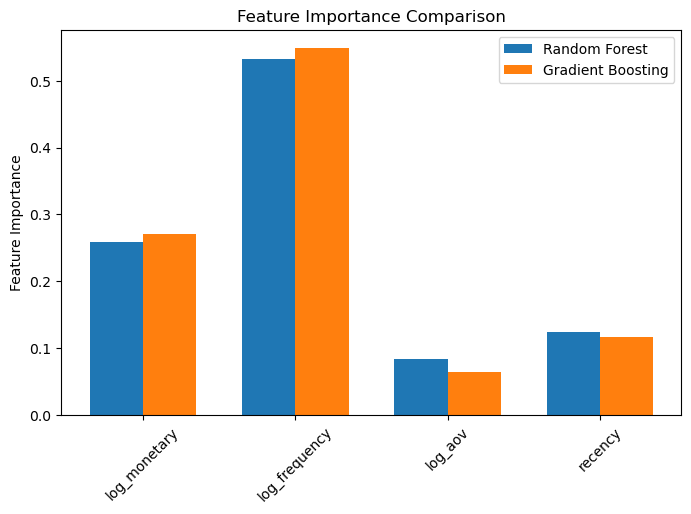

In [62]:
### - Plotting of feature importance

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, rf_importance, width, label='Random Forest')
ax.bar(x + width/2, gb_importance, width, label='Gradient Boosting')

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45)
ax.set_ylabel("Feature Importance")
ax.set_title("Feature Importance Comparison")
ax.legend()

plt.show()

Both models found the exact same thing: Frequency is the dominant driver of predictions. 

The business insight to take away is that **frequency is the strongest predictor of future revenue**.  In other words, it is those customers who purchase more often are the most valuable in the next 60 days.  This makes sense because frequent buyerss are active, engaged, and likely to return.

From the table one can see that Frequency has an importance of 55% of predictive power.  This storngly suggests that customer engagement drives revenue.

Monetary is the second strongest predictor.  In other words, customers who spent a lot of money historically also tend to generate revenue again.  Yet, one could spend a lot of money on a single purchase and still not be a loyal customer.  Thus, frequency is a stronger gauge of customer consistency.

Recent customers are also likely to buy again.  However, recency alone doesn't guarantee future purchases.

AOV helps but doesn't reveal how often someone buys. For instance, a customer could make a 200 pound purchase one time.  Another customer, in the same amount of time, makes five purchases of 40 pounds each.  Even though their Monetary is the same, Customer A has a higher AOV than Customer B.  However, Customer B is more valuable since they make purchases more frequently.

The original question was "Which customers should be prioritized for targeted promotions?"  My model suggets that the company should prioritize customers with high purchase frequency, strong spending history, and recent activity.  Not just the big spenders. The consistency of feature importance rankings across two different models suggets that these relationships are solid and reliable.

***V. Residual Analysis***

The purpose of this section is to check for model bias, underprediction of high-value customers , and/or overprediction of low-value customers. In other words, how well does my tuned Gradient Boosting model behave.

In [63]:
### - Generate Predictions

y_pred = best_gb.predict(X_test)

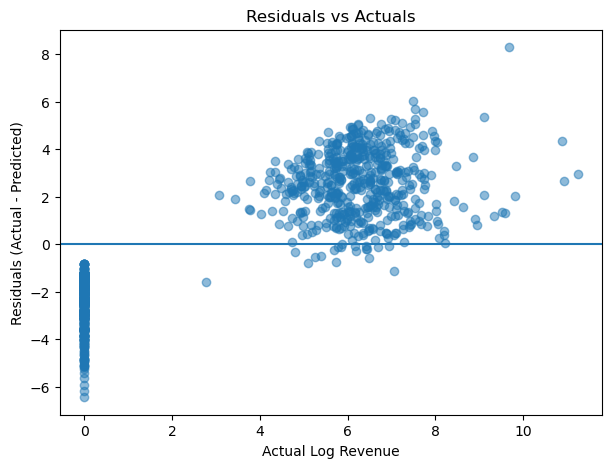

In [64]:
### - Compute the residuals

residuals = y_test - y_pred

### - Create Residuals vs Actuals plot

plt.figure(figsize=(7,5))

plt.scatter(y_test, residuals, alpha=0.5)

plt.axhline(0)  # horizontal line at zero residual
plt.xlabel("Actual Log Revenue")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Actuals")

plt.show()

In [68]:
### - Quantify Residual Plot
res_mean = residuals.mean()
res_med = residuals.median()
print(res_mean, res_med)

-0.036840027298497065 -1.216326624804261


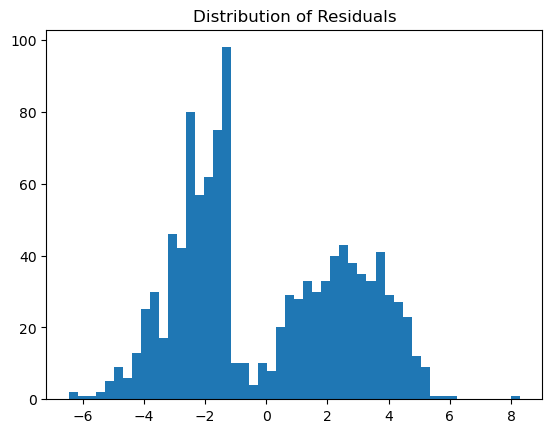

In [71]:
### - Distribution of Residuals

plt.hist(residuals, bins=50)
plt.title("Distribution of Residuals")
plt.show()

Residual analysis shows that prediction errors are generally centered close to zero overall, with a slightly negative median residual. This indicates the model tends to modestly overpredict revenue for many customers, particularly those who ultimately generated little or no revenue during the 60-day window. This behavior is expected in datasets with a large proportion of zero-revenue customers, where models may predict small amounts of revenue for inactive customers. Despite this, the overall distribution of residuals suggests the model does not exhibit strong systematic bias.

This confirms what was seen in the EDA. Namely, that the dataset is zero-heavy.

The residual distribution shows two distinct clusters, reflecting the presence of two different customer behaviors within hte dataset.  The taller cluster corresponds to customers who generated no revenue during the prediction window, where the model tends to silghtly overpredict small amounts of revenue.  The second cluster represents customres who made purchases where prediction errors are more widely distributed.  This pattern highlights the challenge of modeling customer revenue in datasets with a high proportion of zero outcomes.

The key take away is the model slightly over-predicts inactive customers and slightly under-predicts active customers.  This is what creates the "two-lump"distribution.

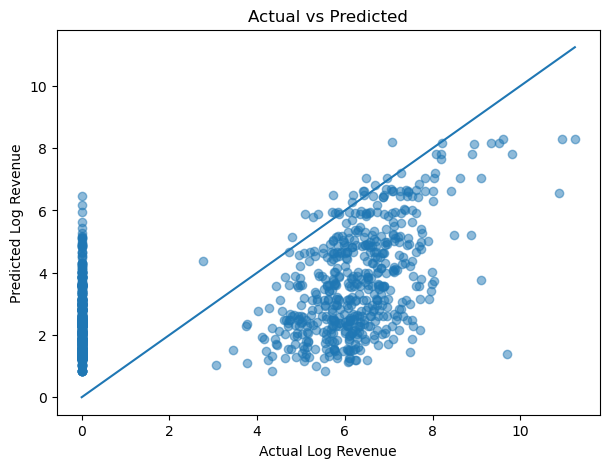

In [72]:
### - Actual vs Predicted

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Log Revenue")
plt.ylabel("Predicted Log Revenue")
plt.title("Actual vs Predicted")

plt.show()

The model demonstrates a strong positive relationship between actual and predicted revenue. However, predictions for high-revenue customers tend to fall below the ideal prediction line, indicating that the model slightly underestimates customers with very high future spending. This may be due to the skewed distribution of spending and the rarity of extreme values.

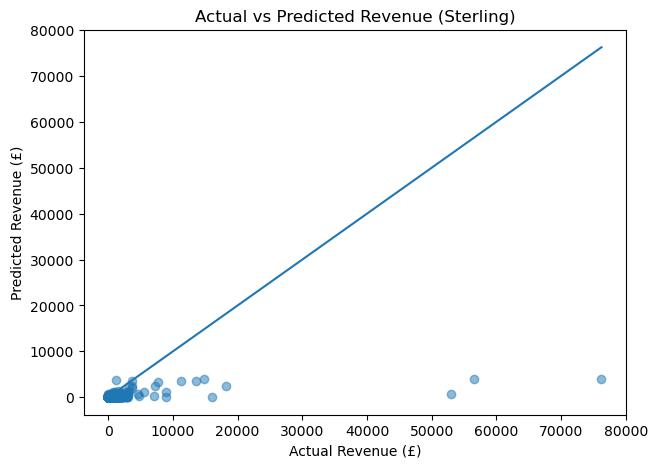

In [73]:
### - Actual Revenue vs Predicted Revenue - NO LOGS

y_test_pounds = np.expm1(y_test)
y_pred_pounds = np.expm1(y_pred)

plt.figure(figsize=(7,5))
plt.scatter(y_test_pounds, y_pred_pounds, alpha=0.5)

plt.plot(
    [y_test_pounds.min(), y_test_pounds.max()],
    [y_test_pounds.min(), y_test_pounds.max()]
)

plt.xlabel("Actual Revenue (£)")
plt.ylabel("Predicted Revenue (£)")
plt.title("Actual vs Predicted Revenue (Sterling)")

plt.show()

When visualizing predictions in Sterling (£), a large concentration of customers appears near zero revenue, reflecting the significant proportion of customers who did not generate purchases within the 60-day window. Most predicted values fall below the perfect prediction line, indicating the model tends to produce conservative revenue estimates, particularly for high-value customers. This pattern is expected when modeling log-transformed revenue data and converting predictions back to the original scale. Despite this visual pattern, the model effectively captures customer revenue trends and maintains strong predictive performance as measured by RMSE in log space.

***VI. Final Modeling Report***

**Model Performance**

Three models were evaluated to predict customer revenue in the next 60 days: Ridge Regression, Random Forest, and Gradient Boosting. Model performance was assessed using Root Mean Squared Error (RMSE) on the test set in log-transformed revenue space, with results also converted back to Sterling (£) for business interpretation.

All three models performed similarly, with Gradient Boosting achieving the lowest RMSE. The final RMSE corresponds to an average prediction error of approximately £14.76 per customer.

This suggests the model is able to reasonably estimate near-term customer value while handling the highly skewed distribution of retail revenue.

**Key Drivers of Future Revenue**

Feature importance analysis from both Random Forest and Gradient Boosting models revealed consistent results across algorithms. The most important predictor of future revenue was purchase frequency, followed by historical spending (monetary value), recency, and average order value.

This indicates that customers who purchase more frequently are significantly more likely to generate revenue in the near future. Historical spending behavior also contributes meaningfully, while recency provides additional predictive signal. Average order value contributes less predictive power compared to the other RFM variables.

The consistency of feature importance rankings across models strengthens confidence in these findings.

**Model Diagnostics**

Residual analysis showed that prediction errors are generally centered around zero, suggesting the model does not exhibit strong systematic bias. A vertical concentration of observations occurs at zero revenue, reflecting the large proportion of customers who did not make purchases during the 60-day prediction window.

When visualized in Sterling (£), predictions appear conservative, with the model tending to slightly underpredict high-revenue customers. This behavior is expected due to the highly skewed nature of retail spending data and the use of a log-transformed target variable during training.

Importantly, no strong heteroskedasticity was observed, indicating that prediction error remains relatively stable across different revenue levels.

**Business Implications**

The modeling results provide clear guidance for promotional targeting strategies. Customers with higher purchase frequency and stronger historical spending patterns are most likely to generate revenue in the near term. These customers should be prioritized for targeted promotions to maximize short-term customer value.

Additionally, the presence of many customers with zero predicted revenue highlights an opportunity to identify segments that may require re-engagement strategies rather than standard promotional campaigns.